In [1]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import expm, expm_multiply
from scipy.sparse.linalg import norm
import matplotlib.pyplot as plt

## Classical error bound

From Lemma 13 in "Quantum algorithms for computing observables of nonlinear partial differential equations", the classsical cost is
$$
    O(d^{2d+3} T (1/\epsilon)^{6d+3}).
$$

## Quantum error bound 

In our method, we can give an explicit construction of a quantum circuit.
We need $T^2 / \epsilon$ layers of gates, coming from the first-order Trotter-Suzuki formula.
By Jordan decomposition, we can assume $A$ is 3-sparse.

If we use the unary coding, we have a depth 3 layer of $ZZ$ and $Z$ rotation gates.
There is a depth 1 layer of $Y$ rotation gates.
For interactions between different variables, there is also $ZZY$ (and some additional 1 or 2 tensor operators), for which there is a depth 4 decomposition.
There are at most $3d$ interactions we need to deal with, so the depth of this part is $O(nd)$.

Taking into account spatial discretization, we need $1/n=h=O(\epsilon^2 / d)$, so $n=O(d/\epsilon^2)$.

Thus, the overall depth is $O(d^2 T^2 / \epsilon^3)$.

Need to also take into account the leakage error.

In [2]:
def get_P(N):
    h = 1/(N-1)
    H = diags([-1j * np.ones(N-1), 1j * np.ones(N-1)], offsets=[1 ,-1]) / (2 * h)

    return H.tocsc()

def get_P_cycle(N):
    assert N >= 3
    h = 1/(N-1)
    H = diags([-1j * np.ones(N-1), 1j * np.ones(N-1)], offsets=[1 ,-1])
    H = H.tolil()
    H[0,-1] = 1j
    H[-1,0] = -1j

    return H.tocsc() / (2 * h)

In [3]:
def get_adj(N):
    h = 1/(N-1)
    H = diags([np.ones(N-1), np.ones(N-1)], offsets=[1 ,-1]) / (2 * h)

    return H

In [6]:
T = 1
N_vals = np.array([50,100, 200, 250, 300, 350, 400, 450, 500])
h_vals = 1/(N_vals-1)
errors = []
max_exp_norm = []
error_bound = []
for i in range(len(N_vals)):
    N = N_vals[i]

    psi_0 = np.zeros(N)
    mu = int(0.2 * (N-1)) / (N-1)
    sigma = 0.04
    for j in range(N):
        psi_0[j] = np.exp(-0.5 * ((j / (N-1) - mu) / sigma) ** 2)

    psi_0 /= np.linalg.norm(psi_0)

    psi = expm_multiply(-1j * get_P_cycle(N), psi_0)

    psi_true = np.zeros((N,N))
    for j in range(N):
        # print(j / (N-1))
        psi_true[i,j] = np.exp(-0.5 * ((j / (N-1) - 1 - mu) / sigma) ** 2)

    psi_true[i] /= np.linalg.norm(psi_true[i])

    errors.append(np.linalg.norm(psi[i] - psi_true[i]))
    # errors.append(norm(expm(-1j * get_P_cycle(N) * T) - expm(-1j * get_P(N) * T)))
    # max_exp_norm.append(max(norm(get_P_cycle(N)), norm(get_P(N))))
    # error_bound.append(T * norm(get_P_cycle(N)-get_P(N)) * max(T * norm(get_P_cycle(N)), T *norm(get_P(N))))

In [7]:
log_h_vals = np.log(h_vals)
log_errors = np.log(errors)


In [8]:
np.polyfit(log_h_vals, log_errors, 1)

array([0.11504903, 0.66639087])

In [9]:
np.polyfit(log_h_vals, np.log(h_vals ** 2 + 1 / np.sqrt(h_vals)), 1)

array([-4.99978417e-01,  1.26162049e-04])

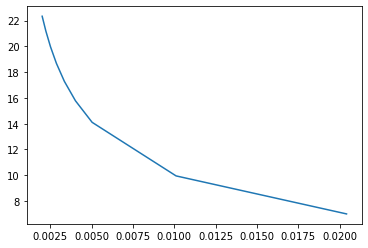

In [10]:
plt.plot(h_vals, h_vals ** 2 + 1 / np.sqrt(h_vals))
plt.show()

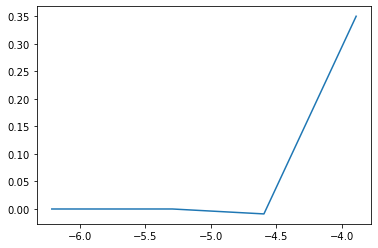

In [11]:
plt.plot(log_h_vals, log_errors)
plt.show()

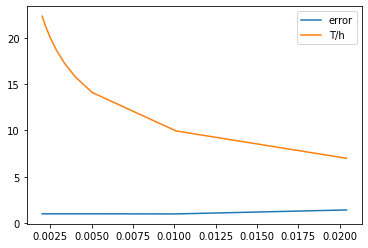

In [13]:
plt.plot(h_vals, errors, label="error")
plt.plot(h_vals, T / np.sqrt(h_vals), label="T/h")
# plt.plot(h_vals, error_bound, label="error bound")
plt.legend()
plt.show()

In [92]:
expm(-1j * get_P_cycle(5) * 1).real.toarray()

array([[-0.39675973,  0.39716212,  0.78315947, -0.04683331,  0.26327146],
       [ 0.26327146, -0.39675973,  0.39716212,  0.78315947, -0.04683331],
       [-0.04683331,  0.26327146, -0.39675973,  0.39716212,  0.78315947],
       [ 0.78315947, -0.04683331,  0.26327146, -0.39675973,  0.39716212],
       [ 0.39716212,  0.78315947, -0.04683331,  0.26327146, -0.39675973]])

In [101]:
evals, _ = np.linalg.eigh(-1j * get_P_cycle(N).toarray())

In [105]:
A = -1j * get_P_cycle(N).toarray()

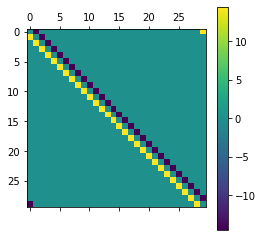

In [108]:
plt.matshow(A.real)
plt.colorbar()
plt.show()

In [111]:
F = np.fft.fft(np.eye(N))/np.sqrt(N)
F_inv = np.linalg.inv(F)

In [146]:
np.exp(-1j * 2 * np.pi * 1 / N) / np.sqrt(N)

(0.17858450183048738-0.037959307676642164j)

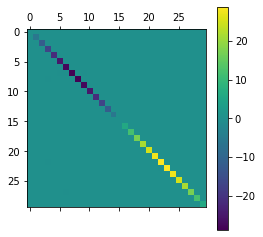

In [136]:
plt.matshow((F @ A.real @ F_inv).imag)
plt.colorbar()
plt.show()

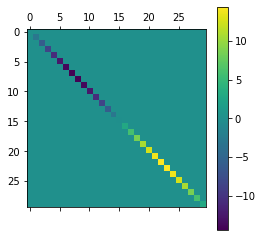

In [137]:
plt.matshow(np.diag(np.array([-np.sin(2 * j * np.pi/ N) * (N-1) / 2 for j in range(N)])))
plt.colorbar()
plt.show()

In [93]:
-1j * get_P_cycle(5)

<5x5 sparse matrix of type '<class 'numpy.complex128'>'
	with 10 stored elements in Compressed Sparse Column format>

In [76]:
h_vals

array([-0.25      , -0.11111111, -0.07142857, -0.05263158, -0.04166667,
       -0.03448276])